In [1]:
from cosipy import BinnedData, UnBinnedData, COSILike
from cosipy import FastTSMap
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response import FullDetectorResponse, PointSourceResponse, ExtendedSourceResponse

# from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, Powerlaw, Cauchy, DiracDelta, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
import mhealpy as hp
from tqdm import tqdm

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r', 'gold', 'crimson', 'slateblue', 'teal']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

20:43:34 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=312030;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=107033;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=94630;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=565488;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=856832;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=193948;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=564592;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=387621;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

20:43:36 WARNING   No fermitools installed                                              ]8;id=931426;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=722668;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=702294;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=427752;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=453666;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=176471;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=980084;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=161932;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
# Data directory
DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC3/')

crab_coord = SkyCoord.from_name('crab').galactic

#### 511 keV

In [ ]:
bg = BinnedData("inputs_511.yaml")
crab = BinnedData("inputs_511.yaml")
nova = BinnedData("inputs_511.yaml")

energy_binwidth = 'log'#np.diff(bg.energy_bins).astype(int)[0]
name = 'continuum'

In [4]:
bg.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')
bg_filename = DATA_DIR / f'nova/binned_bg_energy_{energy_binwidth}keV'

if bg_filename.with_suffix('.hdf5').is_file():
    bg.load_binned_data_from_hdf5(bg_filename.with_suffix('.hdf5'))
else:
    bg.get_binned_data(unbinned_data = bg.data_file, output_name = bg_filename)

In [5]:
nova.data_file = str(DATA_DIR / f'nova/sources/nova_co_{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
nova_filename = DATA_DIR / f'nova/binned_nova_energy_{energy_binwidth}keV'

# if nova_filename.with_suffix('.hdf5').is_file():
#     nova.load_binned_data_from_hdf5(nova_filename.with_suffix('.hdf5'))
# else:
#     nova.get_binned_data(unbinned_data = nova.data_file, output_name = nova_filename)
nova.get_binned_data(unbinned_data = nova.data_file, output_name = nova_filename)

In [7]:
crab.data_file = str(DATA_DIR / f'Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')
crab_filename = DATA_DIR / f'nova/binned_crab_energy_{energy_binwidth}keV'

if crab_filename.with_suffix('.hdf5').is_file():
    crab.load_binned_data_from_hdf5(crab_filename.with_suffix('.hdf5'))
else:
    crab.get_binned_data(unbinned_data = crab.data_file, output_name = crab_filename)

In [8]:
data = nova.binned_data.project('Time', 'Em', 'Phi', 'PsiChi') + \
       crab.binned_data.project('Time', 'Em', 'Phi', 'PsiChi') + \
       bg.binned_data.project('Time', 'Em', 'Phi', 'PsiChi')

In [ ]:
F = 100 / u.cm / u.cm / u.s
mu = 511 * u.keV
sigma = 2.0 * u.keV

# spectrum = DiracDelta()
# spectrum.value.value = F.value
# spectrum.value.min_value = F.value / 1e3
# spectrum.value.max_value = F.value * 1e3
# spectrum.value.unit = F.unit / u.keV
# spectrum.zero_point.value = mu.value 
# spectrum.zero_point.min_value = mu.value - 3
# spectrum.zero_point.max_value = mu.value + 3
# spectrum.zero_point.unit = mu.unit
spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.min_value = F.value / 1e3
spectrum.F.max_value = F.value * 1e3
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.min_value = mu.value - 3
spectrum.mu.max_value = mu.value + 3
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.min_value = 0
spectrum.sigma.max_value = sigma.value + 5
spectrum.sigma.unit = sigma.unit

# spectrum.value.free = True
# spectrum.zero_point.free = True
spectrum.F.free = True
spectrum.mu.free = True
spectrum.sigma.free = True

#### Continuum

In [ ]:
K = 10 / u.cm / u.cm / u.s / u.keV
piv = 100 * u.keV
index = -2 * u.dimensionless_unscaled

# spectrum = DiracDelta()
# spectrum.value.value = F.value
# spectrum.value.min_value = F.value / 1e3
# spectrum.value.max_value = F.value * 1e3
# spectrum.value.unit = F.unit / u.keV
# spectrum.zero_point.value = mu.value 
# spectrum.zero_point.min_value = mu.value - 3
# spectrum.zero_point.max_value = mu.value + 3
# spectrum.zero_point.unit = mu.unit
spectrum = Powerlaw()
spectrum.K.value = K.value
spectrum.K.min_value = K.value / 1e3
spectrum.K.max_value = K.value * 1e3
spectrum.K.unit = K.unit
spectrum.piv.value = piv.value 
spectrum.piv.min_value = piv.value / 10
spectrum.piv.max_value = piv.value * 10
spectrum.piv.unit = piv.unit
spectrum.index.value = index.value
spectrum.index.min_value = -4
spectrum.index.max_value = 0
spectrum.index.unit = index.unit

# spectrum.value.free = True
# spectrum.zero_point.free = True
spectrum.K.free = True
spectrum.piv.free = True
spectrum.index.free = True

#### Sanity Check

(<Axes: xlabel='Time [s]'>, <ErrorbarContainer object of 3 artists>)

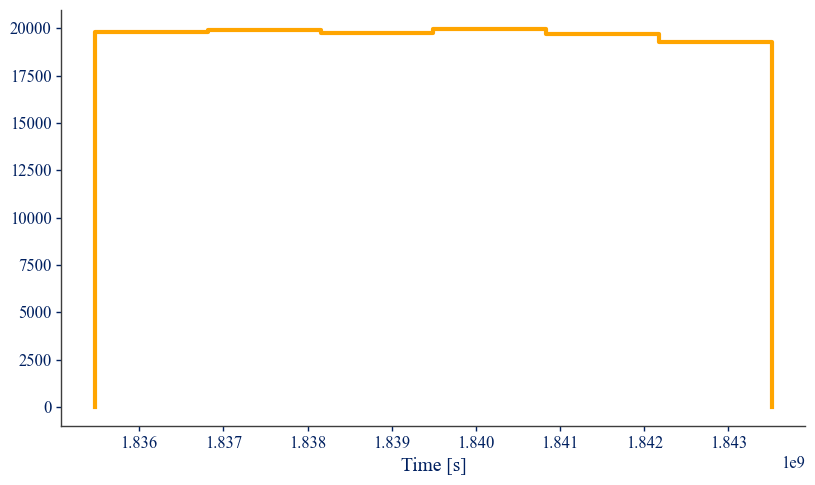

In [10]:
data.project('Time').plot()

(<Axes: xlabel='Em [keV]'>, <ErrorbarContainer object of 3 artists>)

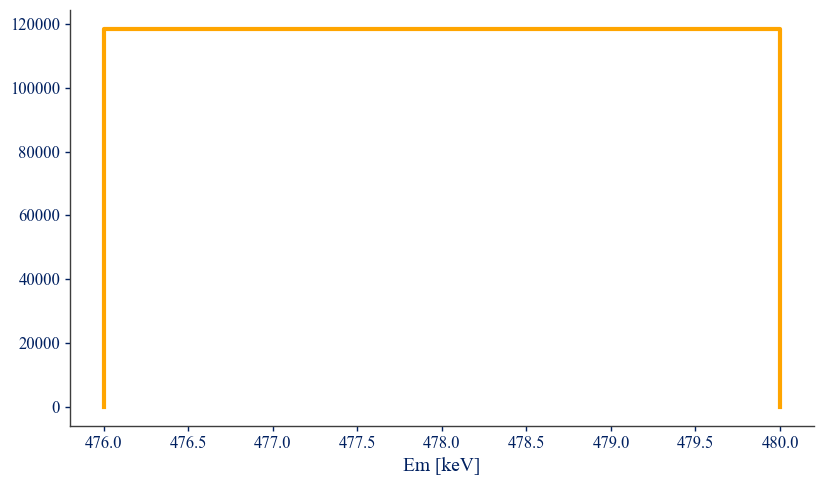

In [9]:
data.project('Em').plot()

In [11]:
data.contents.shape

(6, 1, 60, 3072)

In [11]:
data.slice[1, :, :, :].contents.shape

(1, 1, 60, 3072)

In [13]:
data.rebin([6, 1, 1, 1]).contents.shape

(1, 1, 60, 3072)

### Identify nova location

#### Local CDS Frame

In [ ]:
hypothesis_coords = FastTSMap.get_hypothesis_coords(nside = 16)

AttributeError: type object 'FastTSMap' has no attribute 'get_hypothesis_coords'

In [ ]:
ori_path = DATA_DIR / 'data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori'
ori = SpacecraftFile.parse_from_file(ori_path)

In [ ]:
from astropy.time import Time

nova_tmin = data.axes["Time"].edges[1]
nova_tmax = data.axes["Time"].edges[2]
nova_ori = ori.source_interval(Time(nova_tmin, format = "unix"), Time(nova_tmax, format = "unix"))

In [ ]:
response_path = DATA_DIR / 'data/responses/SMEXv12.511keV.HEALPixO4.binnedimaging.imagingresponse.h5'

In [ ]:
# Create a FastTSMap object. Will fit the TS map in the following cells.
ts = FastTSMap(data = data.slice[1, :, :, :], 
               bkg_model = bg.binned_data.slice[1, :, :, :], 
               orientation = nova_ori, 
               response_path = response_path, 
               cds_frame = "local", 
               scheme = "RING")

In [ ]:
# ts.fast_ts_fit(hypothesis_coords[0], [0, 1], data.slice[1, :, :, :].todense(), bg.binned_data.slice[1, :, :, :].todense(), ori, response_path, spectrum, 'local', 16, 'RING')


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid value encountered in scalar divide


WARNING RuntimeWarning: invalid v

KeyboardInterrupt: 

#### Galactic Frame

In [14]:
# response_path = DATA_DIR / 'data/responses/extended_source_response_511_merged.h5'
response_path = DATA_DIR / 'data/responses/extended_source_response_continuum_merged.h5'

In [4]:
hist = ExtendedSourceResponse.open(response_path)
# new_axes = []

# axis = hist.axes[0]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

# for axis in hist.axes[1:3]:
#     new_axes += [Axis(np.array([476., 480.]) * u.keV,
#                     label = axis.label,
#                     scale = axis.axis_scale)]

# axis = hist.axes[3]
# new_axes += [Axis(axis.edges, label = axis.label,
#                   scale = axis.axis_scale)]

# axis = hist.axes[4]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

# esr_mod = ExtendedSourceResponse(new_axes,
#                                 contents=hist.contents,
#                                 unit=hist.unit)

# esr_mod.write('esr_511_mod.h5')

In [ ]:
# response_path = 'esr_511_mod.h5'

In [12]:
import copy
import healpy as hp
from sparse import COO
import logging
logging.getLogger("healpy").setLevel(logging.WARNING)  # 或 ERROR

def smooth_background(background, fwhm = 5.0 * u.deg):
    
    """
    Smooth the background for TS map fitting. 
    The backrgound shoule have axes as ['Em', 'PsiChi', 'Phi'].
    
    Parameters
    ----------
    background : Histogram
        The background file
    fwhm : astropy.units.quantity.Quantity
    
    Returns
    -------
    Histogram
        The smoothed bakcground
    """
    
    background_smoothed = copy.deepcopy(background)
    
    for i in range(background_smoothed.nbins[0]): # Em bins
        
        for j in range(background_smoothed.nbins[1]): # Phi bins
            
            psichi = background_smoothed[i,j,:]#.todense()
            
            psichi_smoothed = hp.smoothing(psichi, 
                                           fwhm = fwhm.to_value(u.rad), )
                                           #use_pixel_weights=True)
            
            #psichi_smoothed[psichi_smoothed < 0] = 0
            
            background_smoothed[i,j,:] = psichi_smoothed
        
    return background_smoothed

In [13]:
sliced_data = data.project('Em', 'Phi', 'PsiChi').todense()
sliced_bg = (bg.binned_data + crab.binned_data).project('Em', 'Phi', 'PsiChi').todense()

In [14]:
sliced_smooth_bg = smooth_background(sliced_bg)

In [15]:
# Create a FastTSMap object. Will fit the TS map in the following cells.
ts = FastTSMap(
               data = sliced_data, 
               bkg_model = sliced_smooth_bg, 
            #    data = nova.binned_data.project('Em', 'Phi', 'PsiChi').todense(), 
            #    bkg_model = sliced_bg.project('Em', 'Phi', 'PsiChi').todense()*0, 
               orientation = None, 
               response_path = response_path, 
               cds_frame = "galactic",
               )

In [16]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

: 

In [ ]:
# data_cds_array, bkg_model_cds_array, psr_cache = \
#     ts._prepare_inputs(None, spectrum, None)
# hypothesis_coords = ts._get_hypothesis_coords(16)
# ts._fit_one_direction(hypothesis_coords[5], data_cds_array, bkg_model_cds_array, psr_cache)

(<Mollview: >, <matplotlib.image.AxesImage at 0x5112884c0>)

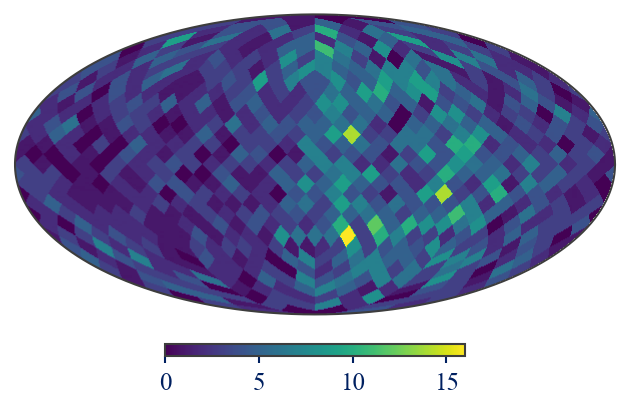

In [12]:
nova.binned_data.slice[:,2,:,:].project('PsiChi').plot()

In [16]:
nova.binned_data.contents.shape

(6, 10, 60, 3072)

(<Mollview: >, <matplotlib.image.AxesImage at 0x330c66bf0>)

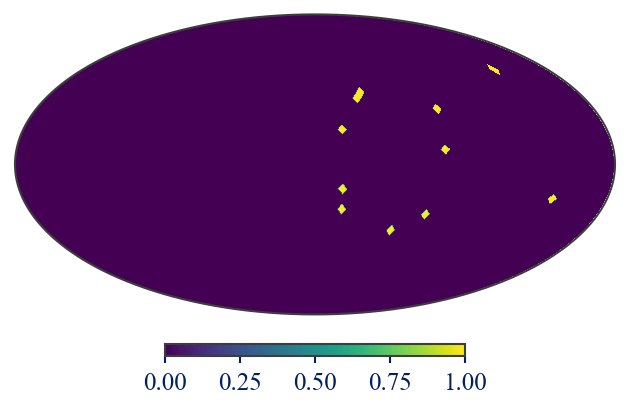

In [41]:
nova.binned_data.slice[:,:,11,:].project('PsiChi').plot()

In [26]:
nova.binned_data.contents.sum()

465.0

In [30]:
ts_results.max()

0

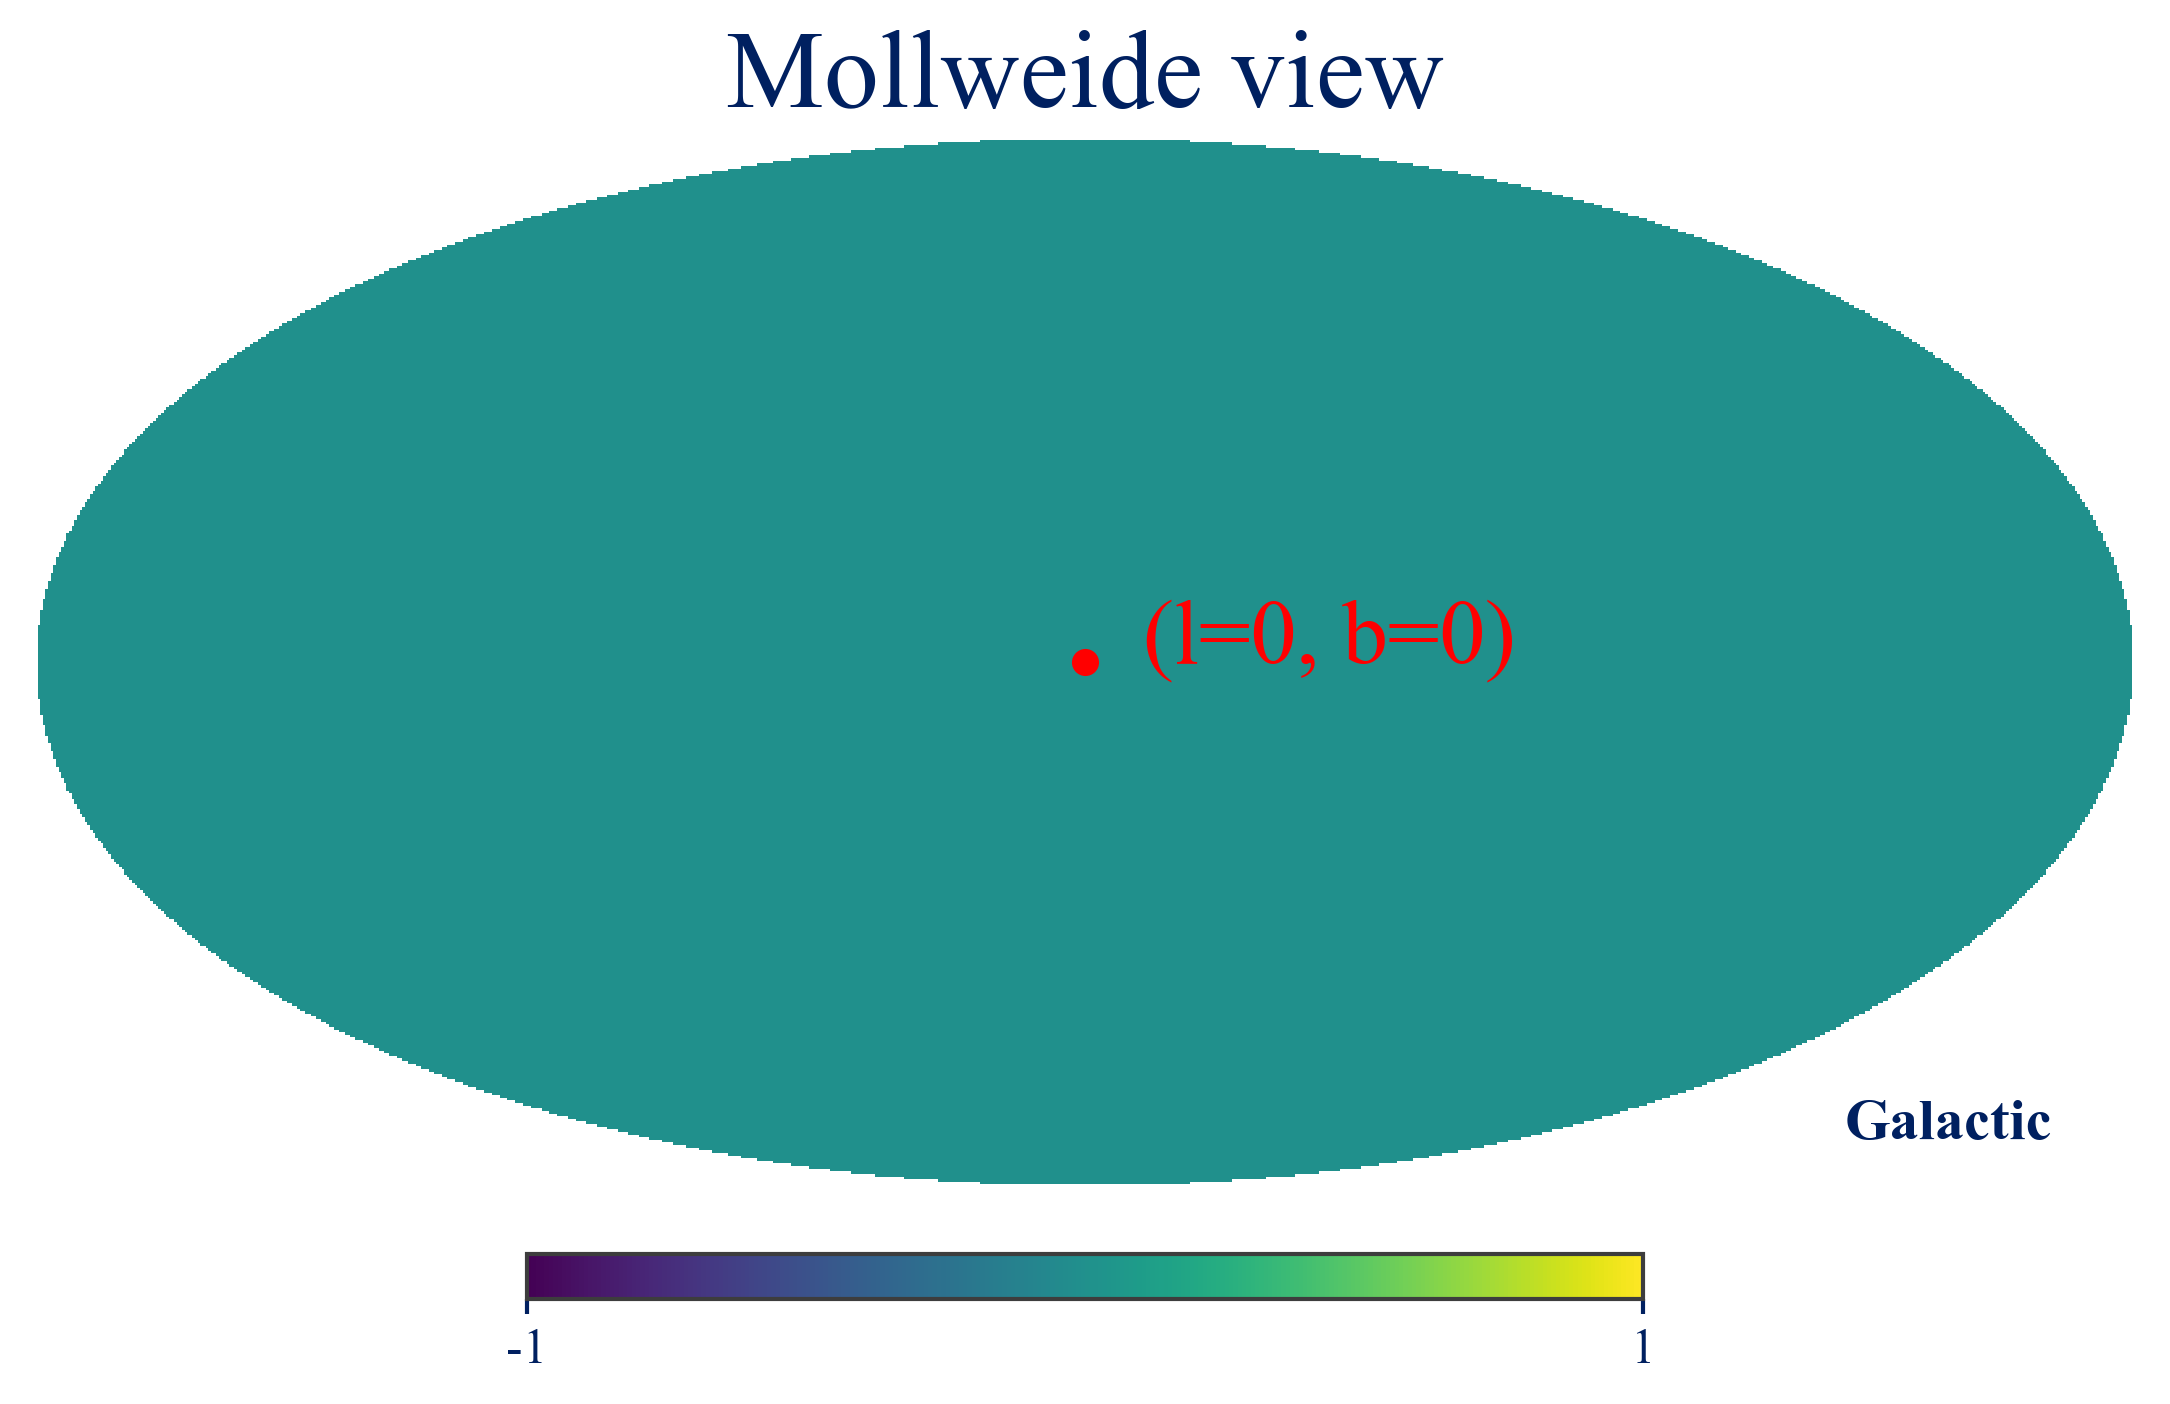

In [17]:
ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

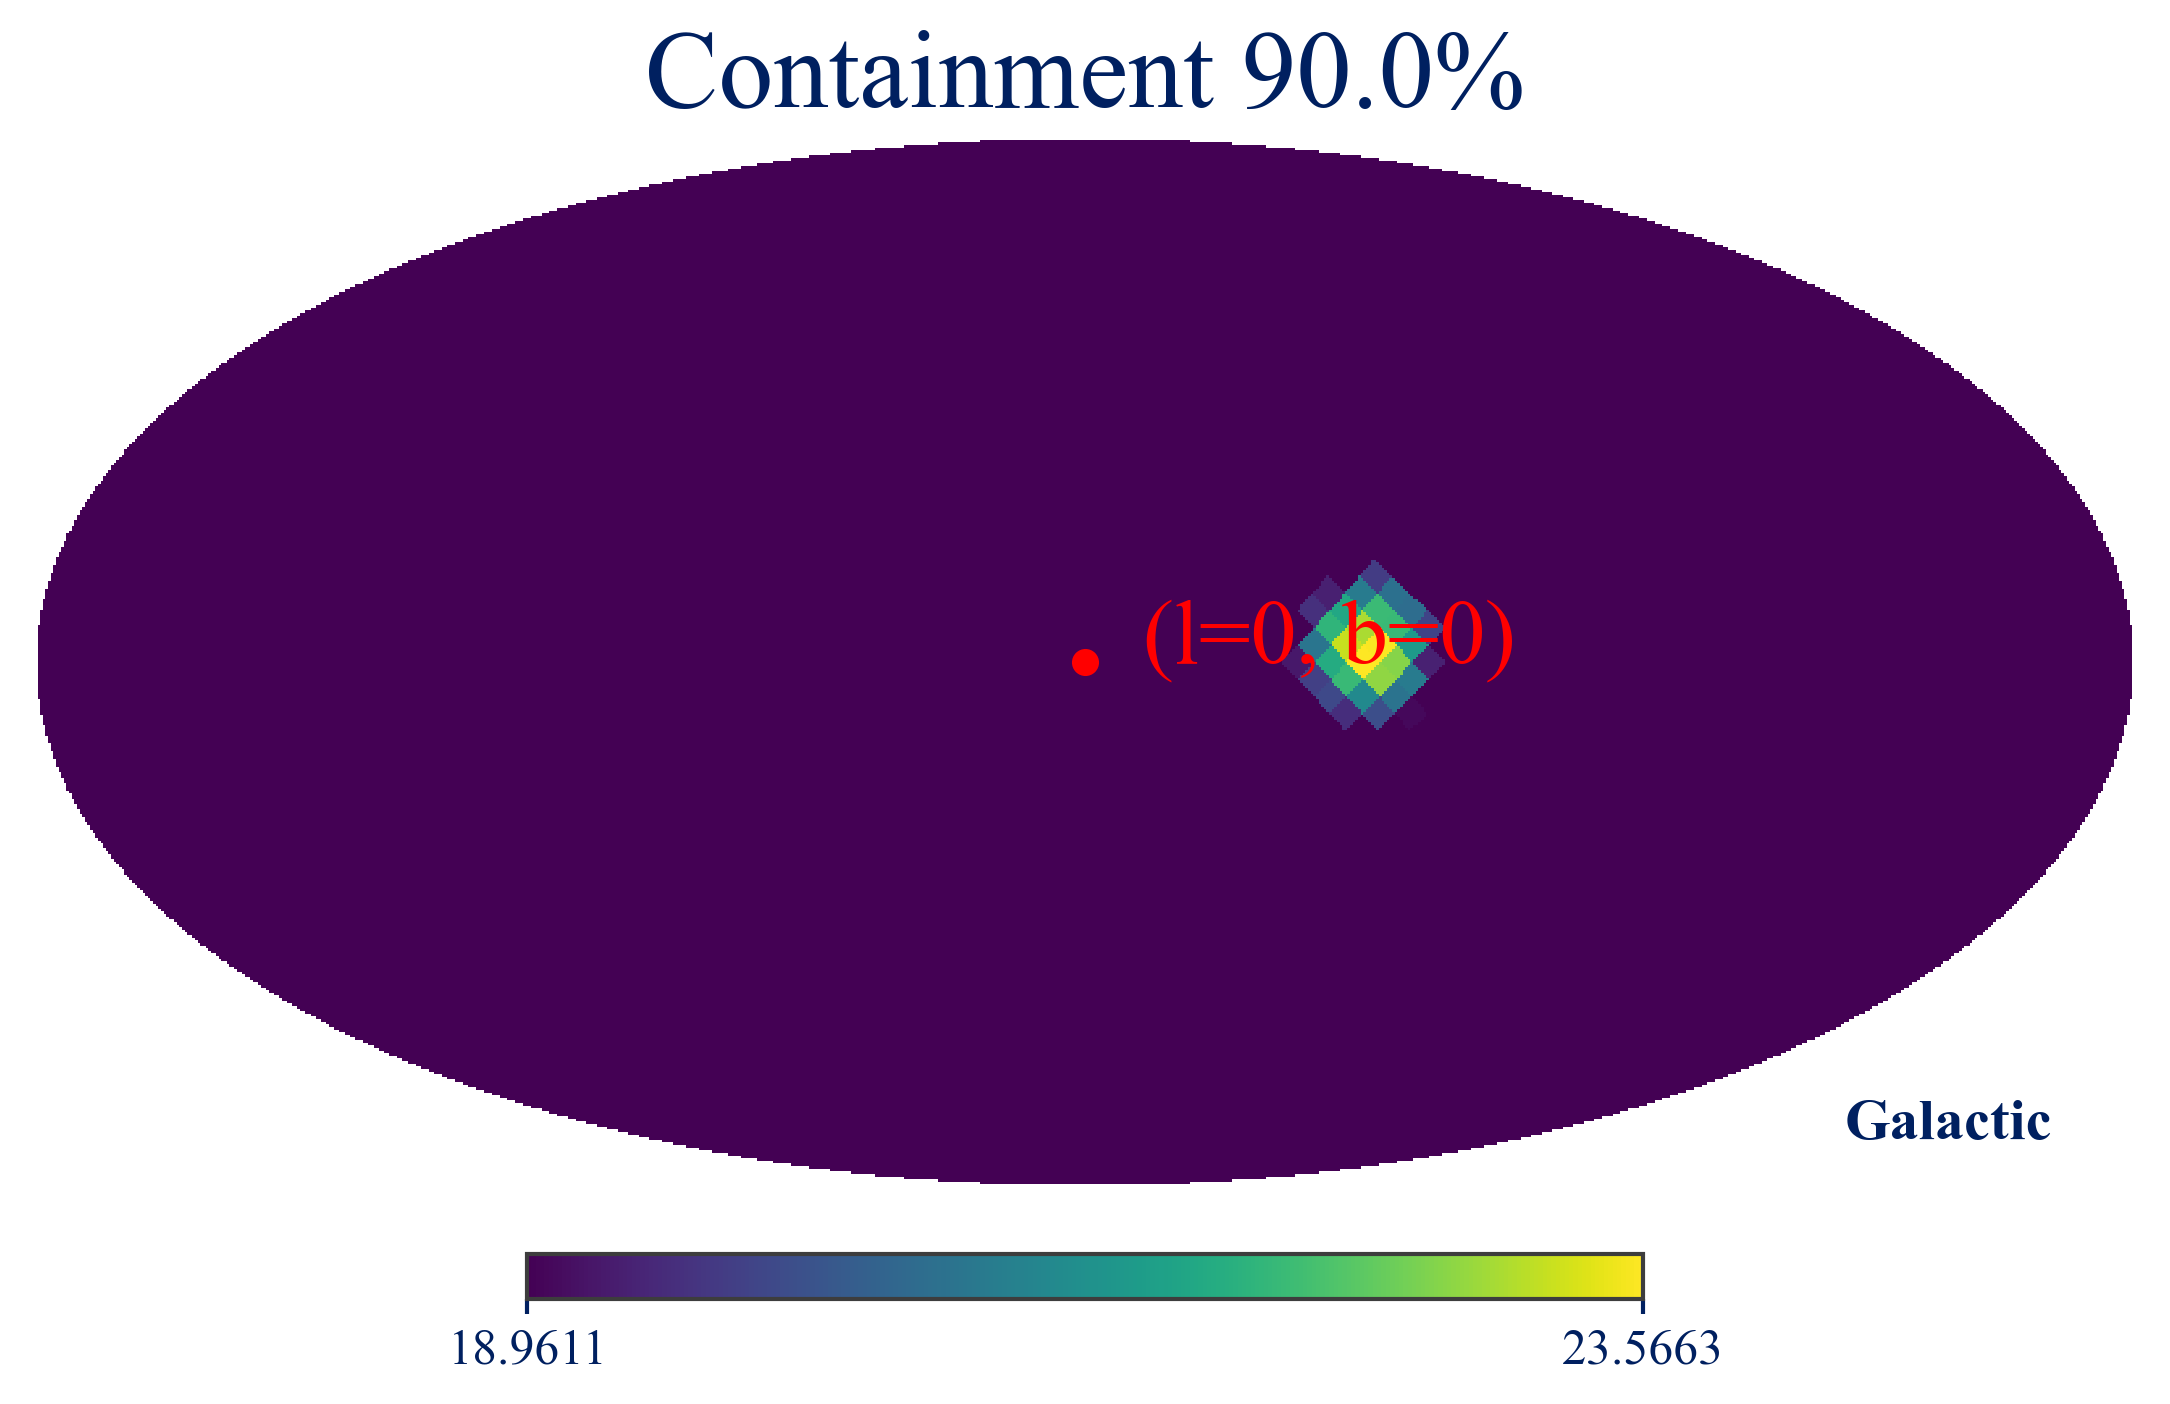

In [39]:
ts.plot_ts(ts_results, containment = 0.9)

### Fit Spectrum

In [51]:
DiracDelta().zero_point

Parameter zero_point = 0.0 []
(min_value = None, max_value = None, delta = 0.1, free = False)